In [1]:
#Import Libs
from matplotlib import pyplot as plot
import matplotlib as mpl
import urllib.request
import urllib.parse
import numpy as np
import math
import cv2

In [2]:
#URL Image
image_url = 'https://raw.githubusercontent.com/jrafa1607/Computational-Vision-In-Python/main/-%20Images/lenna.jpg'

In [3]:
#Open the Image
with urllib.request.urlopen(image_url) as url:
    s = url.read()

In [4]:
#Convert to a Numpy Array and Decode with cv2
img = cv2.imdecode(np.frombuffer(s, np.uint8), -1)

In [5]:
#Convert from BGR to RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

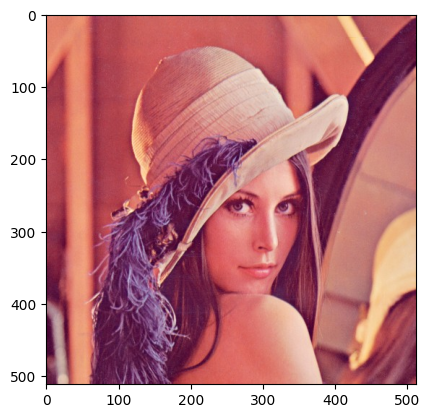

In [6]:
#Show the Image
plot.imshow(img,cmap='gray')
plot.show()

### **Image Color Spaces: RGB, BGR, and Grayscale**

Understanding different color spaces is fundamental in image processing. Here's a brief explanation of **RGB**, **BGR**, and **Grayscale** formats:

*   **RGB (Red, Green, Blue):** RGB is an additive color model where red, green, and blue light are combined in various ways to reproduce a broad array of colors. It's the most common color space for displaying images on screens. Each pixel in an RGB image has three color channels (Red, Green, Blue), and the intensity of each channel determines the final color. For example, (255, 0, 0) is pure red, (0, 255, 0) is pure green, and (0, 0, 255) is pure blue. (0, 0, 0) is black, and (255, 255, 255) is white.

*   **BGR (Blue, Green, Red):** BGR is essentially the same as RGB in terms of color representation, but the order of the color channels is reversed. Instead of Red, Green, Blue, the channels are ordered Blue, Green, Red. This order is commonly used by certain image processing libraries, most notably OpenCV. If you load an image as RGB and then try to display it using a function that expects BGR (or vice-versa), the colors will appear inverted (e.g., reds will look blue, and blues will look red).

*   **Grayscale:** Grayscale images consist of shades of gray, ranging from black to white. Unlike RGB or BGR, a grayscale image has only one channel, representing the intensity or brightness of the pixel. The values typically range from 0 (black) to 255 (white). Grayscale images are often used to simplify image processing tasks, as they reduce the amount of data to be processed while still retaining essential structural information.

In [7]:
# Convert the RGB image to BGR and Grayscale
img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

In [8]:
# Split the RGB image into individual channels
(R, G, B) = cv2.split(img)

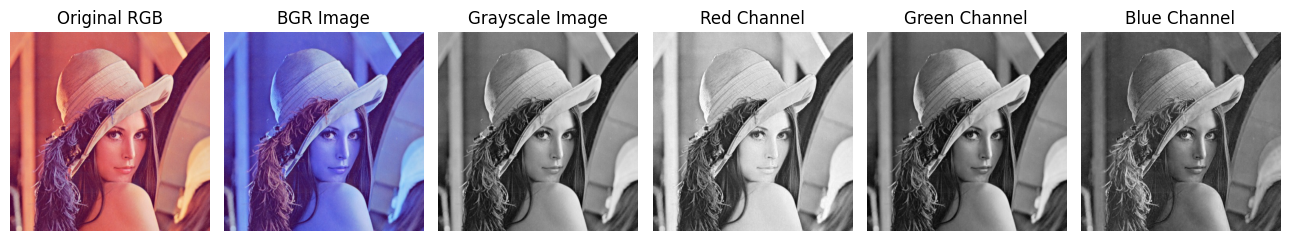

In [9]:
#Show the Results
fig, axes = plot.subplots(1, 6, figsize=(13, 13))
axes = axes.ravel()

# Original RGB Image
axes[0].imshow(img)
axes[0].set_title('Original RGB')
axes[0].axis('off')

# BGR Image
axes[1].imshow(img_bgr)
axes[1].set_title('BGR Image')
axes[1].axis('off')

# Grayscale Image
axes[2].imshow(img_gray, cmap='gray')
axes[2].set_title('Grayscale Image')
axes[2].axis('off')

# Red Channel
axes[3].imshow(R, cmap='gray')
axes[3].set_title('Red Channel')
axes[3].axis('off')

# Green Channel
axes[4].imshow(G, cmap='gray')
axes[4].set_title('Green Channel')
axes[4].axis('off')

# Blue Channel
axes[5].imshow(B, cmap='gray')
axes[5].set_title('Blue Channel')
axes[5].axis('off')

plot.tight_layout()
plot.show()

### **Image Thresholding**

Image thresholding is a simple yet effective technique used to segment an image into two distinct regions: foreground and background. This is typically achieved by setting a threshold value. Pixels with intensity values above the threshold are assigned one value (e.g., white), and pixels below the threshold are assigned another (e.g., black). The result is a binary image, often used as a preliminary step for more complex image analysis tasks.

*   **Binary Thresholding:** In binary thresholding, you manually select a threshold value (`T`). For each pixel in the image, if its intensity `P(x,y)` is greater than `T`, the pixel is set to the maximum value (e.g., 255 for white). If `P(x,y)` is less than or equal to `T`, the pixel is set to the minimum value (e.g., 0 for black).

*   **Otsu's Method for Thresholding:** Otsu's method is an automatic thresholding algorithm that finds an optimal threshold value by maximizing the inter-class variance between the two classes (foreground and background) in the image's grayscale histogram. It assumes that the image contains two classes of pixels (e.g., foreground and background) following a bimodal histogram. The algorithm exhaustively searches for the threshold that minimizes the intra-class variance or, equivalently, maximizes the inter-class variance. This makes it a robust method for images with well-separated intensity distributions, as it doesn't require manual tuning of the threshold value.

In [10]:
# Manual Binary Thresholding
manual_threshold_value = 100
ret_manual, img_manual_bin = cv2.threshold(img_gray, manual_threshold_value, 255, cv2.THRESH_BINARY)

# Otsu's Method for automatic thresholding
ret_otsu, img_otsu_bin = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print(f"Otsu's calculated threshold: {ret_otsu}")

Otsu's calculated threshold: 117.0


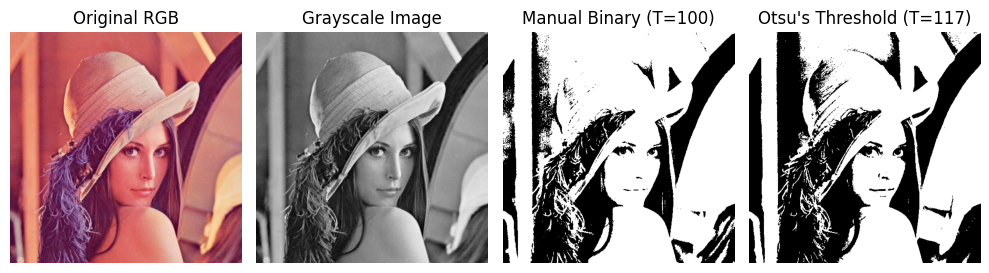

In [11]:
fig, axes = plot.subplots(1, 4, figsize=(10, 10))
axes = axes.ravel()

# Original RGB Image
axes[0].imshow(img)
axes[0].set_title('Original RGB')
axes[0].axis('off')

# Grayscale Image
axes[1].imshow(img_gray, cmap='gray')
axes[1].set_title('Grayscale Image')
axes[1].axis('off')

# Manual Binary Thresholding Result
axes[2].imshow(img_manual_bin, cmap='gray')
axes[2].set_title(f'Manual Binary (T={manual_threshold_value})')
axes[2].axis('off')

# Otsu's Thresholding Result
axes[3].imshow(img_otsu_bin, cmap='gray')
axes[3].set_title(f'Otsu\'s Threshold (T={int(ret_otsu)})')
axes[3].axis('off')

plot.tight_layout()
plot.show()